Saved.


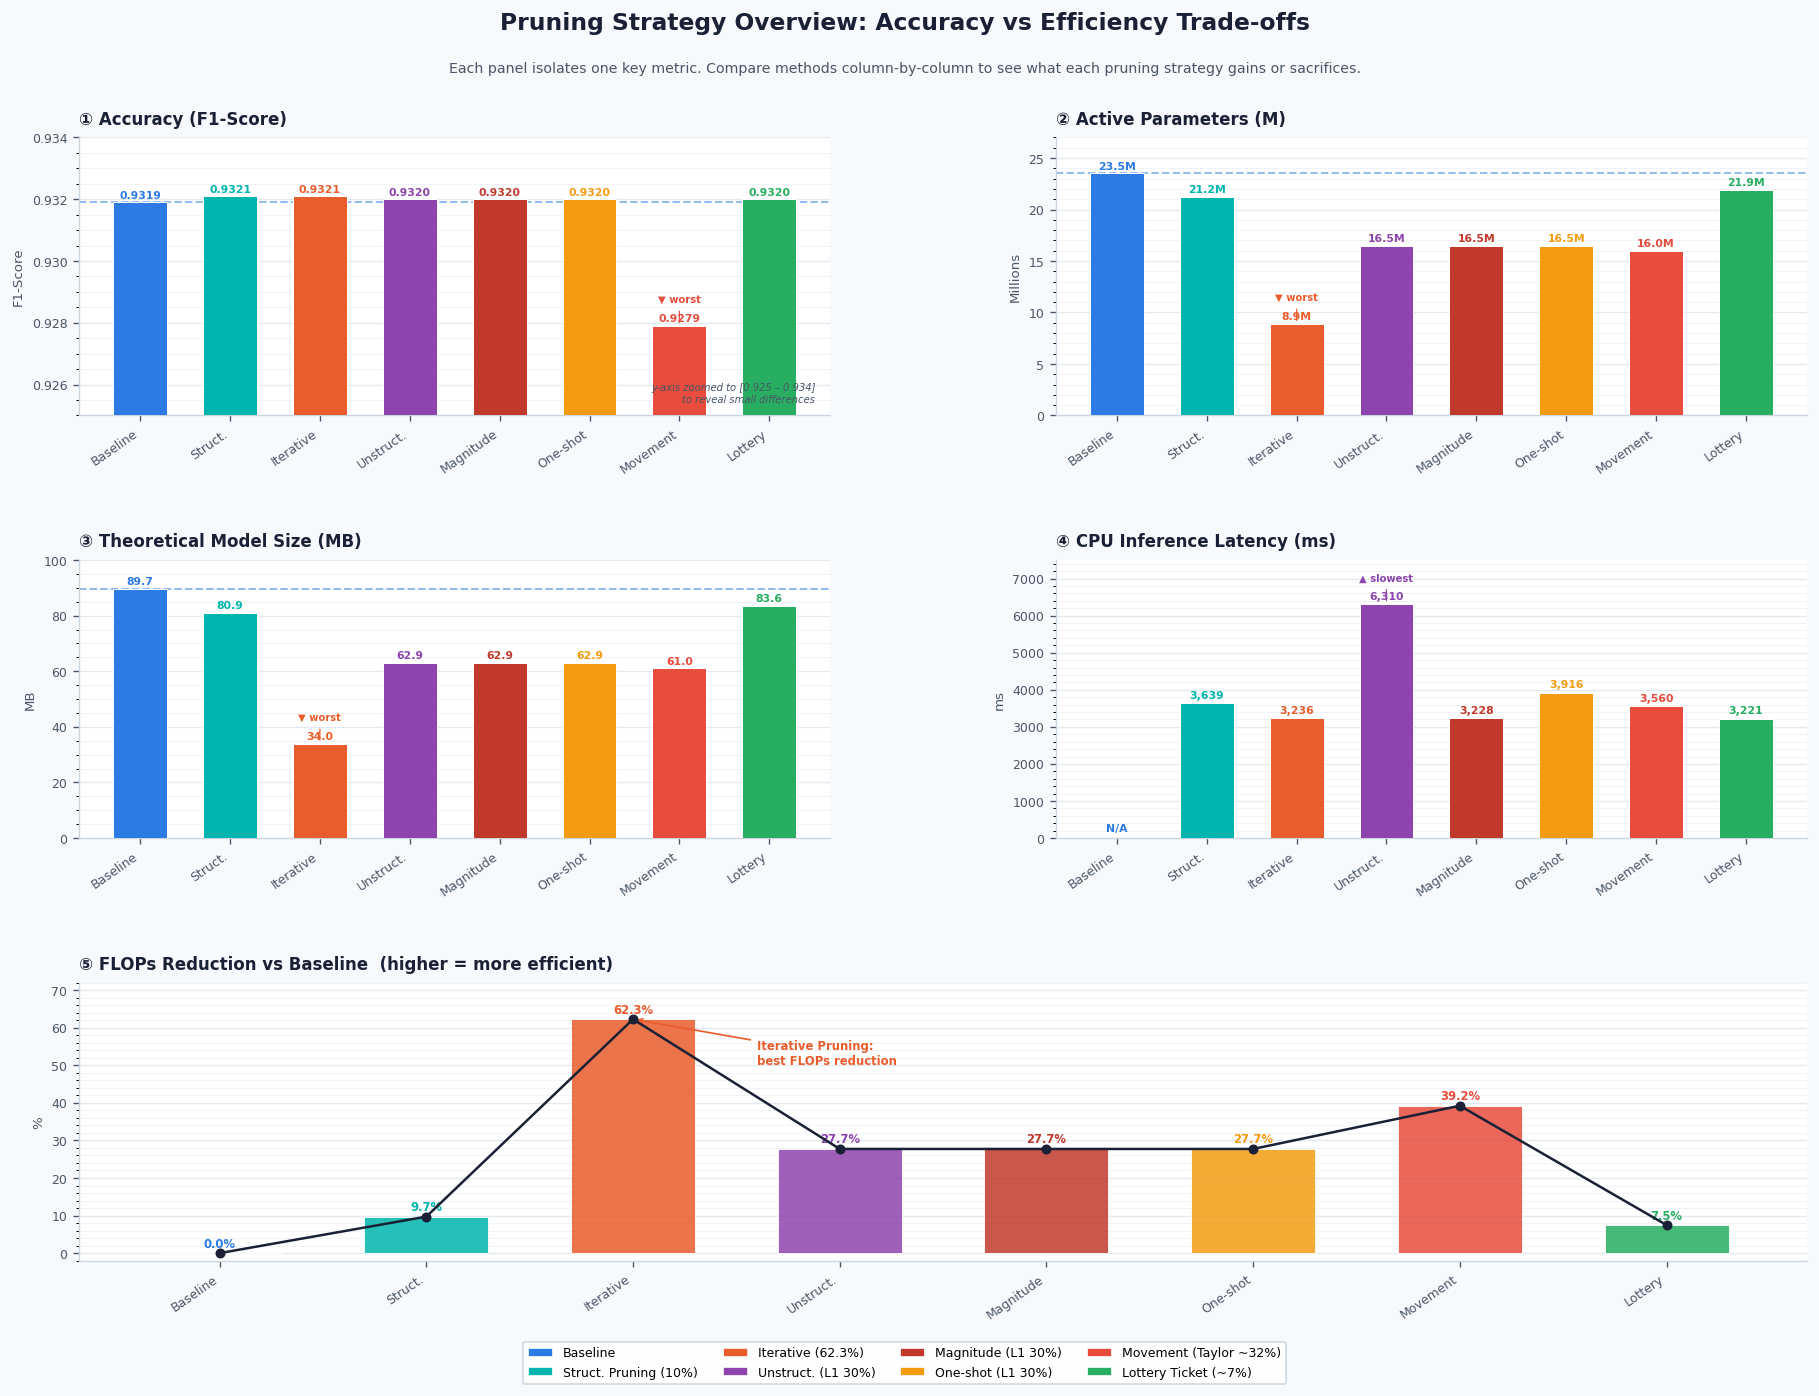

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np

# ── Palette ───────────────────────────────────────────────────────────────────
BG      = "#f7f9fc"
PANEL   = "#ffffff"
GRID    = "#e4e9f0"
TITLE   = "#1a2035"
SUB     = "#4a5568"
BORDER  = "#cbd5e0"

# one colour per method
COLORS = [
    "#2c7be5",   # Baseline         – anchor blue
    "#00b5ad",   # Struct. Pruning  – teal
    "#e95c2b",   # Iterative        – orange-red  (big compressor)
    "#8e44ad",   # Unstruct.        – purple
    "#c0392b",   # Magnitude        – crimson
    "#f39c12",   # One-shot         – amber
    "#e74c3c",   # Movement         – red (worst accuracy)
    "#27ae60",   # Lottery Ticket   – green
]

LABELS = [
    "Baseline",
    "Struct. Pruning (10%)",
    "Iterative (62.3%)",
    "Unstruct. (L1 30%)",
    "Magnitude (L1 30%)",
    "One-shot (L1 30%)",
    "Movement (Taylor ~32%)",
    "Lottery Ticket (~7%)",
]

SHORT = [
    "Baseline", "Struct.", "Iterative", "Unstruct.",
    "Magnitude", "One-shot", "Movement", "Lottery",
]

N = len(LABELS)
x = np.arange(N)
W = 0.6   # bar width

# ── Raw data ──────────────────────────────────────────────────────────────────
f1      = [0.9319, 0.9321, 0.9321, 0.9320, 0.9320, 0.9320, 0.9279, 0.9320]
params  = [23.52,  21.20,   8.90,  16.48,  16.48,  16.48,  15.99,  21.91]   # M
size_mb = [89.72,  80.87,  33.97,  62.87,  62.87,  62.87,  60.99,  83.56]
cpu_ms  = [None,   3639.26, 3236.43, 6310.28, 3228.05, 3916.03, 3560.30, 3220.99]
flops_r = [0,      9.72,   62.26,  27.73,  27.73,  27.73,  39.23,   7.48]   # %

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12), facecolor=BG)
fig.patch.set_facecolor(BG)

gs = gridspec.GridSpec(
    3, 2,
    figure=fig,
    hspace=0.52, wspace=0.30,
    left=0.07, right=0.97,
    top=0.88, bottom=0.10,
)

axes = [
    fig.add_subplot(gs[0, 0]),  # F1-Score
    fig.add_subplot(gs[0, 1]),  # Active Params
    fig.add_subplot(gs[1, 0]),  # Model Size
    fig.add_subplot(gs[1, 1]),  # CPU Inference
    fig.add_subplot(gs[2, :]),  # FLOPs Reduction (full width)
]

def style_ax(ax, title, ylabel, ytop=None, ybot=None):
    ax.set_facecolor(PANEL)
    ax.set_title(title, fontsize=10, fontweight="bold", color=TITLE,
                 pad=8, loc="left", fontfamily="DejaVu Sans")
    ax.set_ylabel(ylabel, fontsize=8, color=SUB)
    ax.set_xticks(x)
    ax.set_xticklabels(SHORT, rotation=35, ha="right", fontsize=7.5, color=SUB)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
    ax.grid(axis="y", which="minor", color=GRID, linewidth=0.3, zorder=0)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color(BORDER)
    ax.tick_params(colors=SUB, labelsize=7.5)
    if ytop is not None: ax.set_ylim(top=ytop)
    if ybot is not None: ax.set_ylim(bottom=ybot)

def bar_plot(ax, values, title, ylabel, baseline_idx=0,
             fmt="{:.3f}", highlight_min=False, highlight_max=False,
             ybot=None, ytop=None):
    bars = ax.bar(x, values, width=W, color=COLORS,
                  edgecolor="white", linewidth=0.6, zorder=3)
    style_ax(ax, title, ylabel, ytop=ytop, ybot=ybot)

    # baseline reference line
    ax.axhline(values[baseline_idx], color=COLORS[baseline_idx],
               linewidth=1.2, linestyle="--", alpha=0.5, zorder=2)

    # value labels on top of bars
    vmin, vmax = min(values), max(values)
    for i, (bar, v) in enumerate(zip(bars, values)):
        label = fmt.format(v)
        offset = (vmax - vmin) * 0.015
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + offset,
                label, ha="center", va="bottom",
                fontsize=6.5, color=COLORS[i], fontweight="bold")

    # crown worst/best
    if highlight_min:
        mi = int(np.argmin(values))
        axes_annotate(ax, bars[mi], "▼ worst", COLORS[mi])
    if highlight_max:
        ma = int(np.argmax(values))
        axes_annotate(ax, bars[ma], "▲ best", COLORS[ma])

def axes_annotate(ax, bar, text, color):
    ax.annotate(text,
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 14), textcoords="offset points",
                ha="center", fontsize=6, color=color, fontweight="bold",
                arrowprops=dict(arrowstyle="-", color=color, lw=0.7))

# ── Panel 1 · F1-Score ────────────────────────────────────────────────────────
bar_plot(axes[0], f1,
         "① Accuracy (F1-Score)", "F1-Score",
         fmt="{:.4f}", highlight_min=True,
         ybot=0.925, ytop=0.9340)
# zoom note
axes[0].text(0.98, 0.04, "y-axis zoomed to [0.925 – 0.934]\nto reveal small differences",
             transform=axes[0].transAxes, ha="right", va="bottom",
             fontsize=6, color=SUB, style="italic")

# ── Panel 2 · Active Parameters ──────────────────────────────────────────────
bar_plot(axes[1], params,
         "② Active Parameters (M)", "Millions",
         fmt="{:.1f}M", highlight_min=True,
         ybot=0, ytop=27)

# ── Panel 3 · Model Size ─────────────────────────────────────────────────────
bar_plot(axes[2], size_mb,
         "③ Theoretical Model Size (MB)", "MB",
         fmt="{:.1f}", highlight_min=True,
         ybot=0, ytop=100)

# ── Panel 4 · CPU Inference ──────────────────────────────────────────────────
cpu_plot = [v if v else 0 for v in cpu_ms]   # 0 for baseline (N/A)
bars4 = axes[3].bar(x, cpu_plot, width=W, color=COLORS,
                    edgecolor="white", linewidth=0.6, zorder=3)
style_ax(axes[3], "④ CPU Inference Latency (ms)", "ms", ybot=0, ytop=7500)
vmin4, vmax4 = min(v for v in cpu_ms if v), max(cpu_ms[1:])
for i, (bar, v) in enumerate(zip(bars4, cpu_ms)):
    if v is None:
        axes[3].text(bar.get_x() + bar.get_width()/2,
                     120, "N/A", ha="center", va="bottom",
                     fontsize=6.5, color=COLORS[i], fontweight="bold")
    else:
        axes[3].text(bar.get_x() + bar.get_width()/2,
                     v + 80, f"{v:,.0f}", ha="center", va="bottom",
                     fontsize=6.5, color=COLORS[i], fontweight="bold")
# worst (highest latency)
mi4 = int(np.argmax(cpu_plot))
axes_annotate(axes[3], bars4[mi4], "▲ slowest", COLORS[mi4])

# ── Panel 5 · FLOPs Reduction (full width, line + bar overlay) ───────────────
ax5 = axes[4]
ax5.set_facecolor(PANEL)
bars5 = ax5.bar(x, flops_r, width=W, color=COLORS,
                edgecolor="white", linewidth=0.6, zorder=3, alpha=0.85)
ax5.plot(x, flops_r, color="#1a2035", linewidth=1.5,
         marker="o", markersize=5, zorder=4, label="FLOPs Reduction %")

style_ax(ax5, "⑤ FLOPs Reduction vs Baseline  (higher = more efficient)", "%",
         ybot=-2, ytop=72)
for i, (bar, v) in enumerate(zip(bars5, flops_r)):
    ax5.text(bar.get_x() + bar.get_width()/2,
             v + 0.8, f"{v:.1f}%", ha="center", va="bottom",
             fontsize=7, color=COLORS[i], fontweight="bold")

# annotate Iterative as the big winner
ax5.annotate("Iterative Pruning:\nbest FLOPs reduction",
             xy=(x[2], flops_r[2]), xytext=(x[2]+0.6, flops_r[2]-12),
             fontsize=7, color=COLORS[2], fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=COLORS[2], lw=1.0))

# ── Super-title & subtitle ────────────────────────────────────────────────────
fig.text(0.5, 0.955,
         "Pruning Strategy Overview: Accuracy vs Efficiency Trade-offs",
         ha="center", fontsize=14, fontweight="bold", color=TITLE)
fig.text(0.5, 0.925,
         "Each panel isolates one key metric. Compare methods column-by-column to see "
         "what each pruning strategy gains or sacrifices.",
         ha="center", fontsize=8.5, color=SUB)

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [mpatches.Patch(facecolor=c, label=l, edgecolor="white")
           for c, l in zip(COLORS, LABELS)]
fig.legend(handles=handles, loc="lower center", ncol=4,
           fontsize=7.5, frameon=True, framealpha=0.9,
           edgecolor=BORDER, facecolor=PANEL,
           bbox_to_anchor=(0.5, 0.01))

plt.savefig("./pruning_overview_diagram.png",
            dpi=180, bbox_inches="tight",
            facecolor=BG, edgecolor="none")
print("Saved.")